# 22 — Gateway Decision Analysis: LSTM Surrogate vs Ground Truth (U-ED-LSTM Helpdesk)

For each **decision point** (gateway) in the process, trains two decision trees
on identical prefixes:

1. **LSTM Surrogate** — target = model's predicted next activity
2. **Ground Truth** — target = actual next activity from the event log

Compares rules, feature importances, and agreement to reveal whether the LSTM
has learned the same decision logic that exists in the data.

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from src.interpretability.surrogate.c45_tree import C45Classifier

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

from src.interpretability.config.helpdesk_config import CONFIG
CONFIG.use_improved = False  # set True for the improved variant
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- Feature indices ---
ACT_IDX = 0    # Activity
RES_IDX = 1    # Resource
VAR_IDX = 2    # Variant index (case-level)

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')

print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')
print(f'Cat features: {decoder.cat_features}')
print(f'Num features: {decoder.num_features}')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Dataset: 6077 sequences, 12 cat, 4 num, seq_len=18
Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '12

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Activity vocabulary (16), EOS=5
Cat features: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
Num features: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


## Build DFG and identify qualifying gateways

A gateway is an activity with more than one observed successor. We filter to
gateways with at least `MIN_CASES` prefixes and at least two branches with
`MIN_BRANCH` cases each, so the decision trees have enough data.

In [3]:
MIN_CASES = 20       # minimum prefixes at this gateway
MIN_BRANCH = 1      # minimum cases per branch (need at least 2 branches above this)
MIN_SAMPLES_LEAF = 20

ACTIVITY_WINDOW = 10                # number of recent events to include as positional features
CASE_LEVEL_THRESHOLD = 0.95     # feature is case-level if it's constant within a case in >=95% of cases

# --- Collect unique cases (longest trace per case_id) ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

print(f'{len(cases)} unique cases')

# --- Data-driven classification: event-level vs case-level ---
# A feature is case-level if at least CASE_LEVEL_THRESHOLD of cases have a single
# constant value across all real (non-EOS) events of the case.
_n_cat_const = [0] * n_cat
_n_num_const = [0] * n_num
_total_checked = 0
for _cid, (_idx, _L) in cases.items():
    _cat_t, _num_t, _ = dataset[_idx]
    _s = seq_len - _L
    _useful = _L
    for _j in range(_L - 1, -1, -1):
        if _cat_t[ACT_IDX][_s + _j].item() == eos_idx:
            _useful = _j
        else:
            break
    if _useful == 0:
        continue
    _total_checked += 1
    for _ci in range(n_cat):
        _vals = _cat_t[_ci][_s:_s + _useful].tolist()
        if len(set(_vals)) == 1:
            _n_cat_const[_ci] += 1
    for _ni in range(n_num):
        _vals = _num_t[_ni][_s:_s + _useful].tolist()
        if max(_vals) - min(_vals) < 1e-6:
            _n_num_const[_ni] += 1

EVENT_CAT_INDICES = [i for i in range(n_cat)
                     if _n_cat_const[i] / _total_checked < CASE_LEVEL_THRESHOLD]
EVENT_NUM_INDICES = [i for i in range(n_num)
                     if _n_num_const[i] / _total_checked < CASE_LEVEL_THRESHOLD]

print(f'\nFeature classification (threshold: {CASE_LEVEL_THRESHOLD:.0%} constant -> case-level, '
      f'based on {_total_checked} cases):')
for _ci in range(n_cat):
    _pct = _n_cat_const[_ci] / _total_checked
    _tag = 'event-level' if _ci in EVENT_CAT_INDICES else 'CASE-LEVEL'
    print(f'  cat[{_ci}] {decoder.cat_features[_ci]:35s} {_pct:5.1%} constant  -> {_tag}')
for _ni in range(n_num):
    _pct = _n_num_const[_ni] / _total_checked
    _tag = 'event-level' if _ni in EVENT_NUM_INDICES else 'CASE-LEVEL'
    print(f'  num[{_ni}] {decoder.num_features[_ni]:35s} {_pct:5.1%} constant  -> {_tag}')

# --- Build DFG ---
dfg = {}
successors_map = {}

for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    # Strip trailing EOS
    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    # Append synthetic 'EOS' so the case-end transition shows up in the DFG
    # (and gateways with EOS as a successor become qualifying decision points).
    act_names = [activity_names[acts[j].item()] for j in range(useful_len)] + ['EOS']
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

print(f'\nDecision points ({len(decision_points)}):')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c}, {c/total*100:.0f}%)' for s, c in
                         sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total} cases): {branches}')

916 unique cases

Feature classification (threshold: 95% constant -> case-level, based on 916 cases):
  cat[0] Activity                             0.0% constant  -> event-level
  cat[1] Resource                             0.0% constant  -> event-level
  cat[2] Variant index                       100.0% constant  -> CASE-LEVEL
  cat[3] seriousness                         100.0% constant  -> CASE-LEVEL
  cat[4] customer                            99.8% constant  -> CASE-LEVEL
  cat[5] product                             99.9% constant  -> CASE-LEVEL
  cat[6] responsible_section                 100.0% constant  -> CASE-LEVEL
  cat[7] seriousness_2                       97.5% constant  -> CASE-LEVEL
  cat[8] service_level                       98.7% constant  -> CASE-LEVEL
  cat[9] service_type                        99.9% constant  -> CASE-LEVEL
  cat[10] support_section                     100.0% constant  -> CASE-LEVEL
  cat[11] workgroup                           99.9% constant  -> C

## Collect per-gateway prefixes

For each qualifying gateway, find every prefix that ends at that activity (where
a real next activity exists). Extract both the actual next activity and the
LSTM's prediction, plus engineered features for the surrogate trees.

In [ ]:
def extract_features(cat_tuple, num_tuple, decoder):
    """Extract features for a single prefix.

    Kept minimal: prefix_length, case-level features (cat + num) at the gateway
    position, and positional encoding over the last ACTIVITY_WINDOW events for
    every event-level categorical AND numerical feature.
    """
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None

    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len

    feats = {'prefix_length': prefix_len}

    # Case-level categorical features (event-level ones are covered by positional features below)
    for ci, feat_name in enumerate(decoder.cat_features):
        if ci in EVENT_CAT_INDICES:
            continue
        val = cat_tuple[ci][end - 1].item()
        feats[f'last_{feat_name}'] = str(decoder.decode_categorical_value(ci, val))

    # Case-level numerical features (event-level ones are covered by positional features below)
    for ni, feat_name in enumerate(decoder.num_features):
        if ni in EVENT_NUM_INDICES:
            continue
        feats[f'last_{feat_name}'] = decoder.decode_numerical_value(
            feat_name, num_tuple[ni][end - 1].item())

    # Positional features for every event-level categorical feature (last ACTIVITY_WINDOW events)
    for ci in EVENT_CAT_INDICES:
        feat_name = decoder.cat_features[ci]
        tensor = cat_tuple[ci][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_categorical_value(ci, tensor[pos].item())
            else:
                feats[key] = '<pad>'

    # Positional features for every event-level numerical feature (last ACTIVITY_WINDOW events)
    for ni in EVENT_NUM_INDICES:
        feat_name = decoder.num_features[ni]
        tensor = num_tuple[ni][start:end]
        for w in range(1, ACTIVITY_WINDOW + 1):
            pos = prefix_len - w
            key = f'{feat_name}_pos_{-w}'
            if pos >= 0:
                feats[key] = decoder.decode_numerical_value(feat_name, tensor[pos].item())
            else:
                feats[key] = float('nan')

    return feats


# --- Collect gateway data ---
gateway_data = {}  # gateway_name -> {X, y_lstm, y_actual, cat_list, num_list}

for gateway_act, succs in decision_points.items():
    # Check if gateway qualifies
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows = []
    actual_labels = []
    cat_list = []
    num_list = []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        # Strip trailing EOS
        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        # Iterate up to AND including the last real activity. When k == useful_len - 1
        # the next event is EOS (case end) -- include that as a training sample so
        # gateways like 'last_real_act -> EOS' get learned by the surrogate trees.
        for k in range(useful_len):
            act_idx_val = acts[k].item()
            if activity_names[act_idx_val] != gateway_act:
                continue

            if k < useful_len - 1:
                next_act_name = activity_names[acts[k + 1].item()]
            else:
                next_act_name = 'EOS'
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            # Build padded prefix tensors
            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    # Batch-predict LSTM labels
    N = len(X)
    cat_batch = [
        torch.stack([cat_list[i][ci] for i in range(N)])
        for ci in range(n_cat)
    ]
    num_stacked = torch.stack([
        torch.stack(num_list[i], dim=-1) for i in range(N)
    ])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs, 'probs': probs,
        # Prefix tensors so notebook 23 can run IG on the exact rows the trees
        # were trained on without re-collecting / re-stratifying.
        'cat_list': cat_list, 'num_list': num_list,
    }

    # Report
    n_branches_actual = len(set(y_actual))
    n_branches_lstm = len(set(y_lstm))
    lstm_acc = (y_lstm == y_actual).mean()
    print(f'\n{gateway_act}: {N} prefixes, '
          f'{n_branches_actual} actual branches, {n_branches_lstm} LSTM branches, '
          f'LSTM accuracy={lstm_acc:.3f}')
    print(f'  Actual distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_actual, return_counts=True))))
    print(f'  LSTM   distribution: '
          + ', '.join(f'{a} ({c})' for a, c in
                      zip(*np.unique(y_lstm, return_counts=True))))

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')

## Train surrogate and ground truth trees per gateway

For each gateway, the same stratified 60/20/20 train/validation/test
split is used for both trees so they are fit on identical training data,
selected on identical validation data, and evaluated on identical
held-out test data. Depth is swept on the validation set and the
shallowest tree within 2% of the best validation score is selected.
Final fidelity, accuracy, and agreement metrics are reported on the
held-out test set.

In [5]:
def select_best_depth(X_train, y_train, X_val, y_val, cat_features,
                      depths=(3, 4, 5, 6, 7, 8)):
    """Sweep depths on validation set; prefer shallowest within 2% of best."""
    results = []
    for depth in depths:
        clf = C45Classifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train, categorical_features=cat_features)
        train_sc = clf.score(X_train, y_train)
        val_sc = clf.score(X_val, y_val)
        results.append({'depth': depth, 'train': train_sc, 'val': val_sc, 'clf': clf})

    best_idx = 0
    best_val = results[0]['val']
    for i in range(1, len(results)):
        if results[i]['val'] > best_val + 0.02:
            best_idx = i
            best_val = results[i]['val']
    return results[best_idx]['clf'], results


# --- Train trees for each gateway ---
gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    # Identify categorical columns (object dtype)
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    # --- Three-way split: 60% train / 20% validation / 20% test ---
    # First split: 80% trainval / 20% test (held out for final metrics)
    try:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_actual)
    except ValueError:
        X_trainval, X_test, y_lstm_tv, y_lstm_test, y_actual_tv, y_actual_test = \
            train_test_split(X, y_lstm, y_actual, test_size=0.2, random_state=42)

    # Second split: 75% of trainval = 60% total for training, 25% of trainval = 20% total for validation
    try:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25,
                             random_state=42, stratify=y_actual_tv)
    except ValueError:
        X_train, X_val, y_lstm_train, y_lstm_val, y_actual_train, y_actual_val = \
            train_test_split(X_trainval, y_lstm_tv, y_actual_tv, test_size=0.25, random_state=42)

    feature_names = list(X.columns)

    # Train C4.5 trees on train set, select depth on validation set
    clf_lstm, lstm_sweep = select_best_depth(
        X_train, y_lstm_train, X_val, y_lstm_val, cat_cols)
    clf_gt, gt_sweep = select_best_depth(
        X_train, y_actual_train, X_val, y_actual_val, cat_cols)

    # --- Final metrics on held-out TEST set ---
    surrogate_fidelity = clf_lstm.score(X_test, y_lstm_test)
    gt_accuracy = clf_gt.score(X_test, y_actual_test)
    lstm_accuracy = (y_lstm_test == y_actual_test).mean()
    agreement = (clf_lstm.predict(X_test) == clf_gt.predict(X_test)).mean()

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': feature_names,
        'cat_cols': cat_cols,
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_lstm_train': y_lstm_train, 'y_lstm_val': y_lstm_val, 'y_lstm_test': y_lstm_test,
        'y_actual_train': y_actual_train, 'y_actual_val': y_actual_val, 'y_actual_test': y_actual_test,
        'surrogate_fidelity': surrogate_fidelity,
        'gt_accuracy': gt_accuracy,
        'lstm_accuracy': lstm_accuracy,
        'agreement': agreement,
        'n_cases': len(X),
        'lstm_sweep': lstm_sweep, 'gt_sweep': gt_sweep,
    }

    print(f'\n{"=" * 70}')
    print(f'Gateway: {gateway_act} ({len(X)} prefixes: '
          f'{len(X_train)} train / {len(X_val)} val / {len(X_test)} test)')
    print(f'  LSTM accuracy at gateway:     {lstm_accuracy:.3f}')
    print(f'  Surrogate fidelity (vs LSTM): {surrogate_fidelity:.3f}  '
          f'(depth={clf_lstm.get_depth()}, leaves={clf_lstm.get_n_leaves()})')
    print(f'  Ground truth tree accuracy:   {gt_accuracy:.3f}  '
          f'(depth={clf_gt.get_depth()}, leaves={clf_gt.get_n_leaves()})')
    print(f'  Agreement (surrogate vs GT):  {agreement:.3f}')


Gateway: Assign seriousness (995 prefixes: 597 train / 199 val / 199 test)
  LSTM accuracy at gateway:     0.543
  Surrogate fidelity (vs LSTM): 0.603  (depth=2, leaves=3)
  Ground truth tree accuracy:   0.849  (depth=0, leaves=1)
  Agreement (surrogate vs GT):  0.980

Gateway: Take in charge ticket (996 prefixes: 597 train / 199 val / 200 test)
  LSTM accuracy at gateway:     0.645
  Surrogate fidelity (vs LSTM): 0.855  (depth=3, leaves=4)
  Ground truth tree accuracy:   0.680  (depth=3, leaves=4)
  Agreement (surrogate vs GT):  0.970

Gateway: Resolve ticket (988 prefixes: 592 train / 198 val / 198 test)
  LSTM accuracy at gateway:     0.929
  Surrogate fidelity (vs LSTM): 0.949  (depth=0, leaves=1)
  Ground truth tree accuracy:   0.924  (depth=0, leaves=1)
  Agreement (surrogate vs GT):  1.000

Gateway: Closed (916 prefixes: 549 train / 183 val / 184 test)
  LSTM accuracy at gateway:     0.978
  Surrogate fidelity (vs LSTM): 0.995  (depth=0, leaves=1)
  Ground truth tree accuracy: 

## Summary table

In [6]:
summary_rows = []
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_
    top_lstm = fn[np.argmax(imp_lstm)]
    top_gt = fn[np.argmax(imp_gt)]

    summary_rows.append({
        'Gateway': gateway_act,
        '#Cases': gr['n_cases'],
        '#Branches (actual)': len(set(gr['y_actual_train']) | set(gr['y_actual_test'])),
        'LSTM Accuracy': f'{gr["lstm_accuracy"]:.3f}',
        'Surrogate Fidelity': f'{gr["surrogate_fidelity"]:.3f}',
        'GT Tree Accuracy': f'{gr["gt_accuracy"]:.3f}',
        'Agreement': f'{gr["agreement"]:.3f}',
        'Top LSTM Feature': top_lstm,
        'Top GT Feature': top_gt,
        'Same Top Feature': top_lstm == top_gt,
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Gateway,#Cases,#Branches (actual),LSTM Accuracy,Surrogate Fidelity,GT Tree Accuracy,Agreement,Top LSTM Feature,Top GT Feature,Same Top Feature
0,Assign seriousness,995,5,0.543,0.603,0.849,0.980,day_in_week_pos_-2,prefix_length,False
1,Take in charge ticket,996,6,0.645,0.855,0.680,0.970,seconds_in_day_pos_-4,seconds_in_day_pos_-4,True
2,Resolve ticket,988,4,0.929,0.949,0.924,1.000,prefix_length,prefix_length,True
3,Closed,916,3,0.978,0.995,0.973,1.000,prefix_length,prefix_length,True
4,Wait,283,7,0.456,0.684,0.544,0.825,prefix_length,seconds_in_day_pos_-3,False
5,Insert ticket,28,2,0.000,1.000,1.000,0.000,prefix_length,prefix_length,True
6,Require upgrade,21,6,0.000,0.600,0.400,0.000,prefix_length,prefix_length,True


## Feature importance comparison

Side-by-side bar charts: which features does the LSTM surrogate rely on vs
which features explain the actual process decisions?

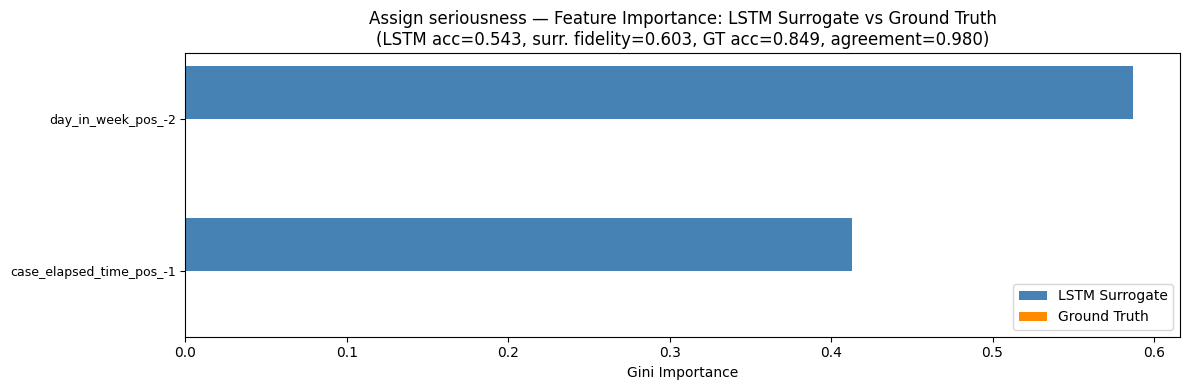

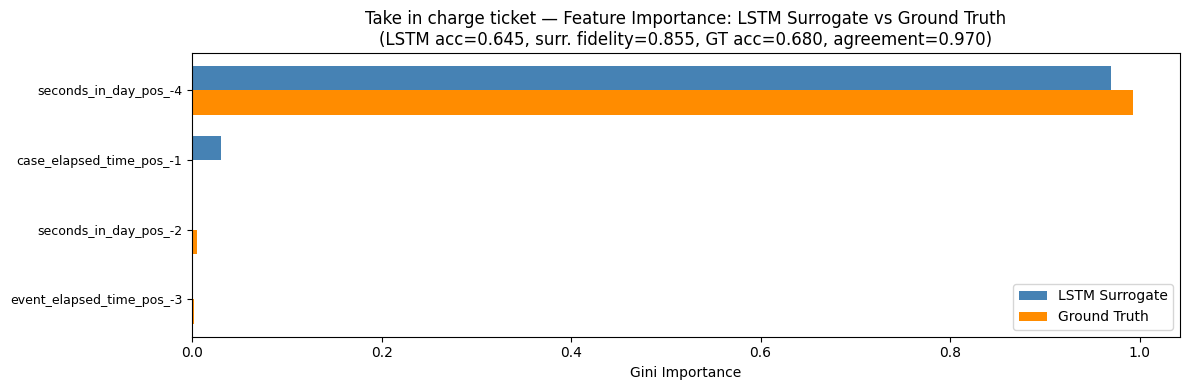

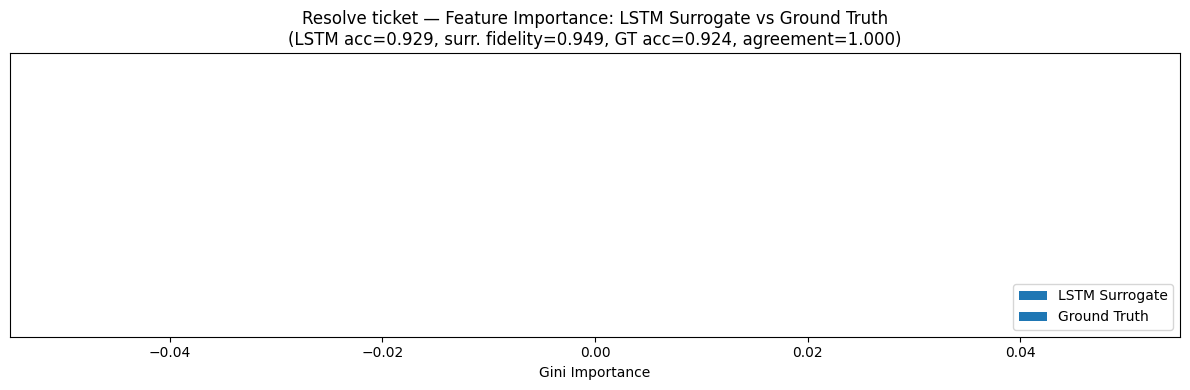

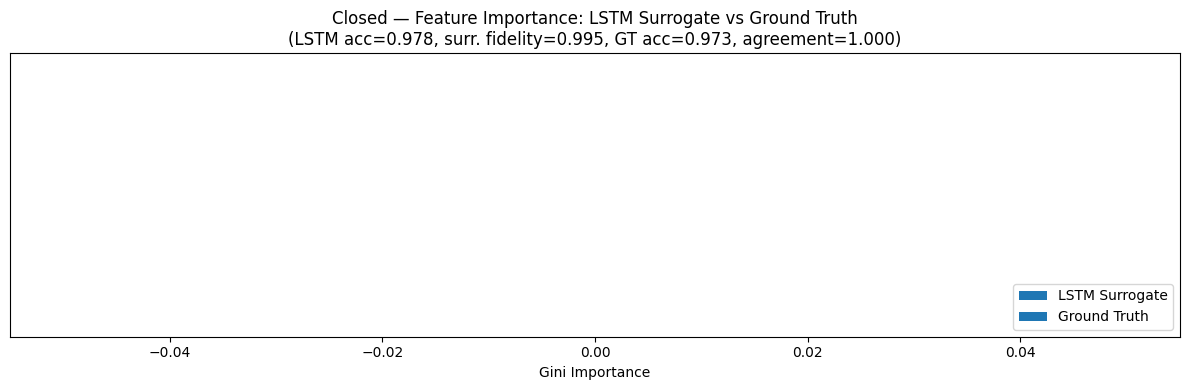

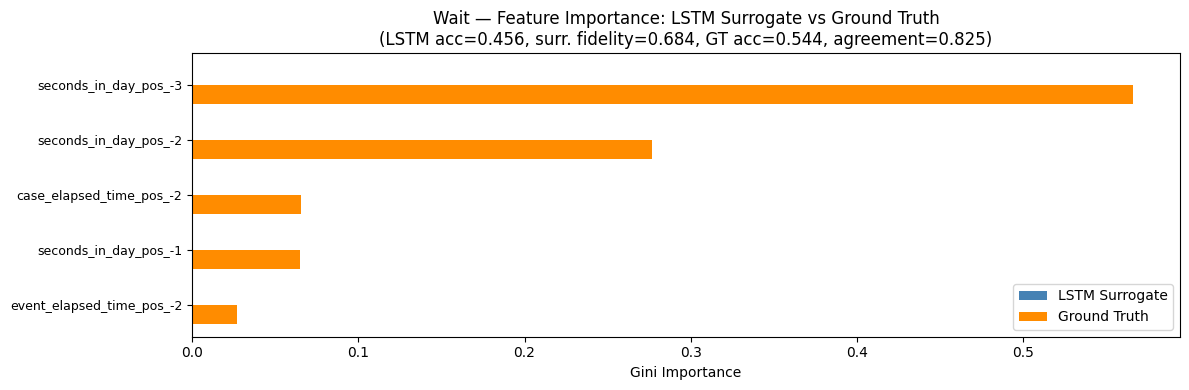

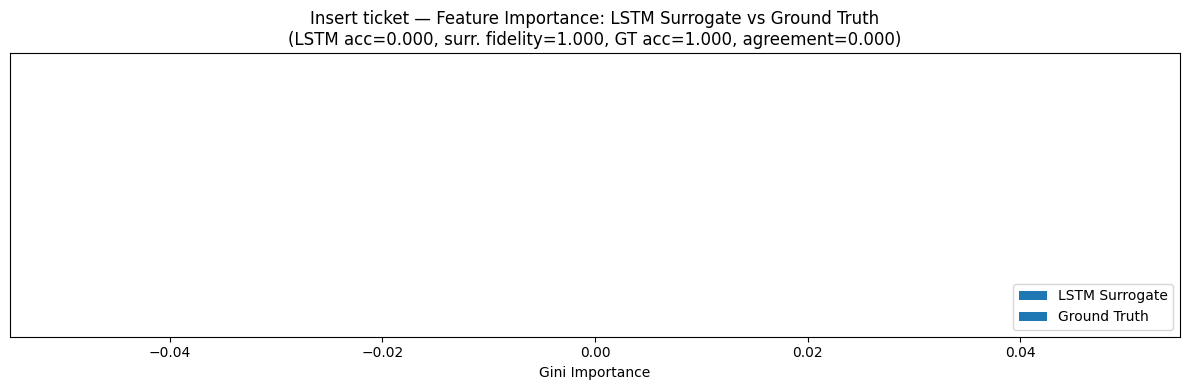

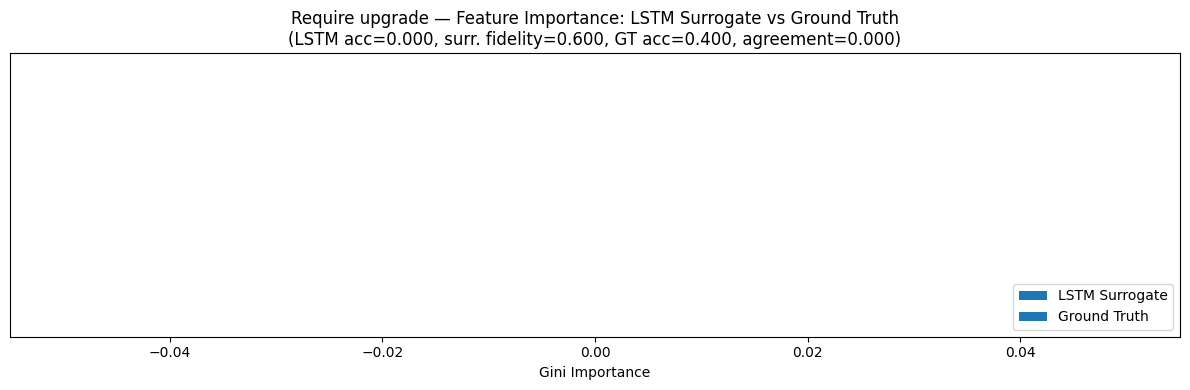

In [7]:
for gateway_act, gr in gateway_results.items():
    fn = gr['feature_names']
    imp_lstm = gr['clf_lstm'].feature_importances_
    imp_gt = gr['clf_gt'].feature_importances_

    # Only show features with non-zero importance in either tree
    mask = (imp_lstm > 0) | (imp_gt > 0)
    fn_nz = [f for f, m in zip(fn, mask) if m]
    imp_lstm_nz = imp_lstm[mask]
    imp_gt_nz = imp_gt[mask]

    # Sort by max importance across both
    order = np.argsort(np.maximum(imp_lstm_nz, imp_gt_nz))[::-1]
    fn_nz = [fn_nz[i] for i in order]
    imp_lstm_nz = imp_lstm_nz[order]
    imp_gt_nz = imp_gt_nz[order]

    fig, ax = plt.subplots(figsize=(12, max(4, len(fn_nz) * 0.4)))
    y_pos = np.arange(len(fn_nz))
    bar_h = 0.35

    ax.barh(y_pos - bar_h / 2, imp_lstm_nz, bar_h, label='LSTM Surrogate', color='steelblue')
    ax.barh(y_pos + bar_h / 2, imp_gt_nz, bar_h, label='Ground Truth', color='darkorange')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(fn_nz, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Gini Importance')
    ax.set_title(f'{gateway_act} — Feature Importance: LSTM Surrogate vs Ground Truth\n'
                 f'(LSTM acc={gr["lstm_accuracy"]:.3f}, '
                 f'surr. fidelity={gr["surrogate_fidelity"]:.3f}, '
                 f'GT acc={gr["gt_accuracy"]:.3f}, '
                 f'agreement={gr["agreement"]:.3f})')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## Side-by-side tree visualizations

Trees are capped at **depth 4** for readability. Full decision logic is in the
if/then rules section below. Split conditions show decoded category names.

In [8]:
# C4.5 trees have multi-way splits and cannot use sklearn's plot_tree.
# Instead, print the tree as readable rules.

def print_tree_rules(clf, label, max_rules=15):
    rules = clf.extract_rules()
    print(f'\n  {label} ({len(rules)} rules, showing top {min(max_rules, len(rules))}):')
    print(f'  {"─" * 70}')
    for i, rule in enumerate(rules[:max_rules]):
        conds = '\n      AND '.join(rule['conditions'])
        print(f'  Rule {i+1} (n={rule["n_samples"]}, {rule["confidence"]:.0%} confidence):')
        print(f'    IF  {conds}')
        print(f'    THEN -> {rule["prediction"]}')
        print()


for gateway_act, gr in gateway_results.items():
    print(f'{"=" * 80}')
    print(f'GATEWAY: {gateway_act}')
    print_tree_rules(gr['clf_lstm'], 'LSTM Surrogate (C4.5)')
    print_tree_rules(gr['clf_gt'], 'Ground Truth (C4.5)')

GATEWAY: Assign seriousness

  LSTM Surrogate (C4.5) (3 rules, showing top 3):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=44, 66% confidence):
    IF  case_elapsed_time_pos_-1 <= 3.049e+05
      AND day_in_week_pos_-2 <= 2.5
    THEN -> Take in charge ticket

  Rule 2 (n=22, 55% confidence):
    IF  case_elapsed_time_pos_-1 <= 3.049e+05
      AND day_in_week_pos_-2 > 2.5
    THEN -> Resolve ticket

  Rule 3 (n=20, 50% confidence):
    IF  case_elapsed_time_pos_-1 > 3.049e+05
    THEN -> Take in charge ticket


  Ground Truth (C4.5) (1 rules, showing top 1):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=597, 84% confidence):
    IF  
    THEN -> Take in charge ticket

GATEWAY: Take in charge ticket

  LSTM Surrogate (C4.5) (4 rules, showing top 4):
  ──────────────────────────────────────────────────────────────────────
  Rule 1 (n=28, 57% confidence):
    IF  seconds_in_day_pos_-4 <= 5.223e+04
      AND ca

## Decision rules as readable if/then statements

Each leaf becomes one rule. Conditions along the path from root to leaf are
combined with AND. Rules are sorted by sample count (most common decisions
first).

In [9]:
# Rule extraction is now built into C45Classifier.extract_rules()
# (printed in the cell above)

## Confusion: surrogate predictions vs ground truth predictions

Where do the two trees disagree? Each cell shows how many test samples the
LSTM surrogate assigned to one branch while the ground truth tree assigned
to another.

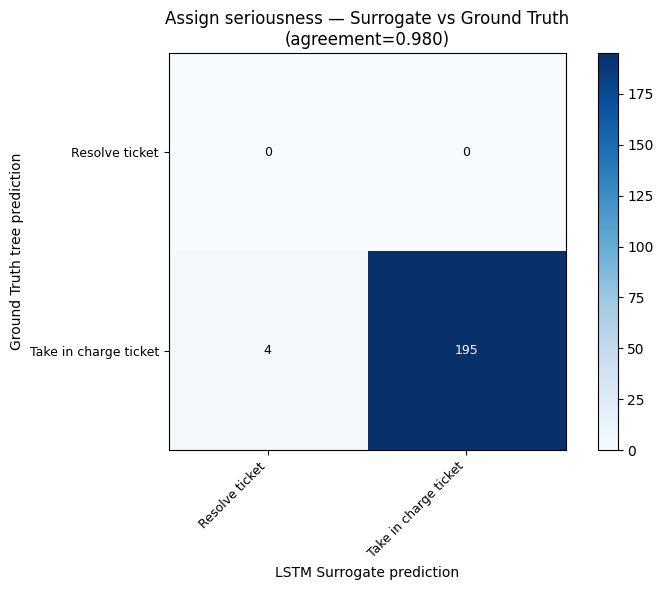

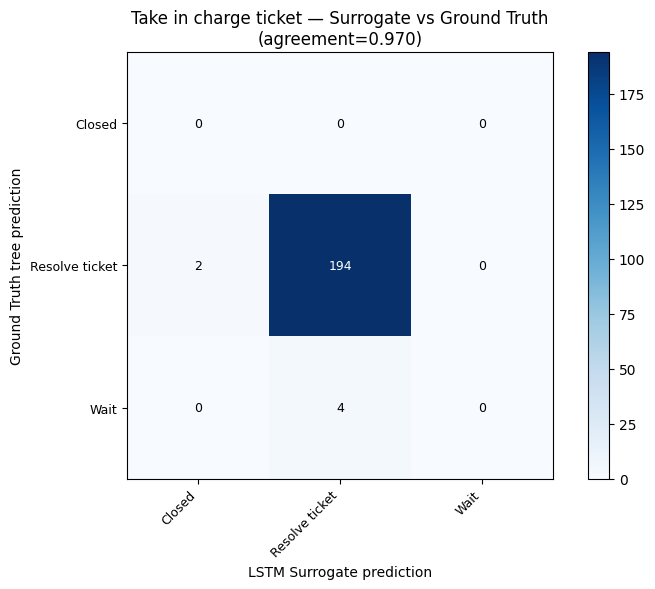

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


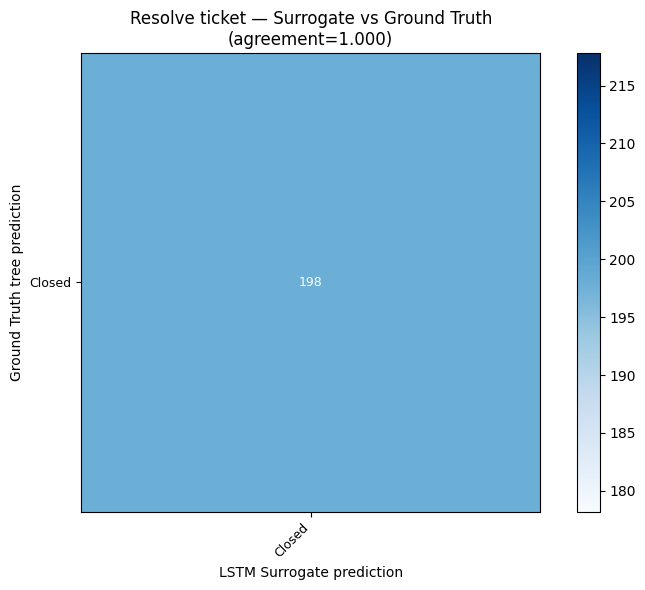

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


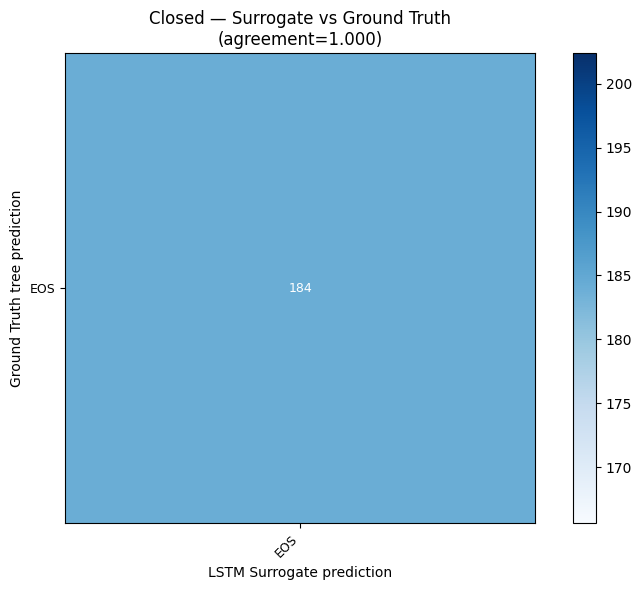

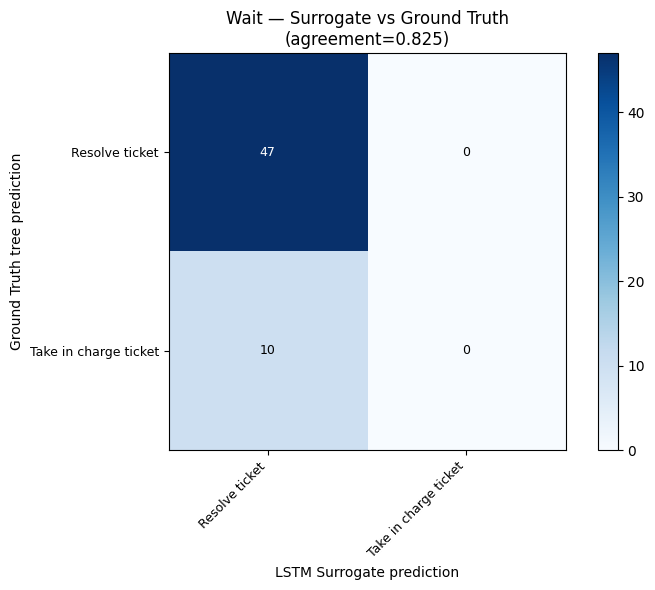

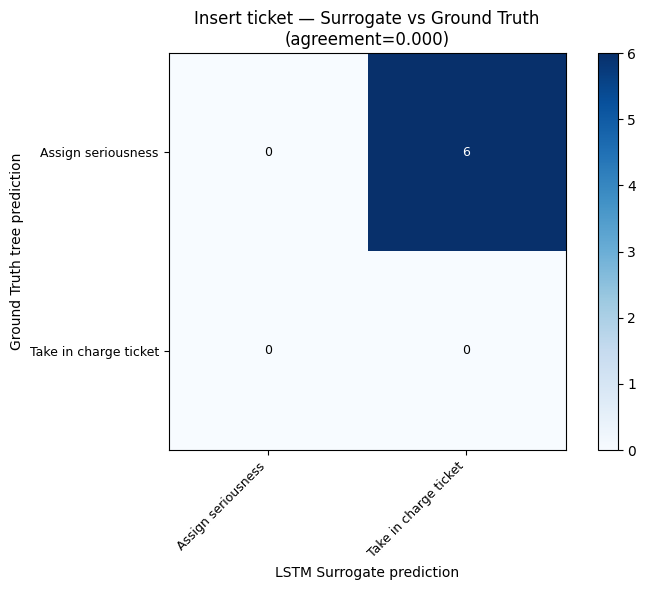

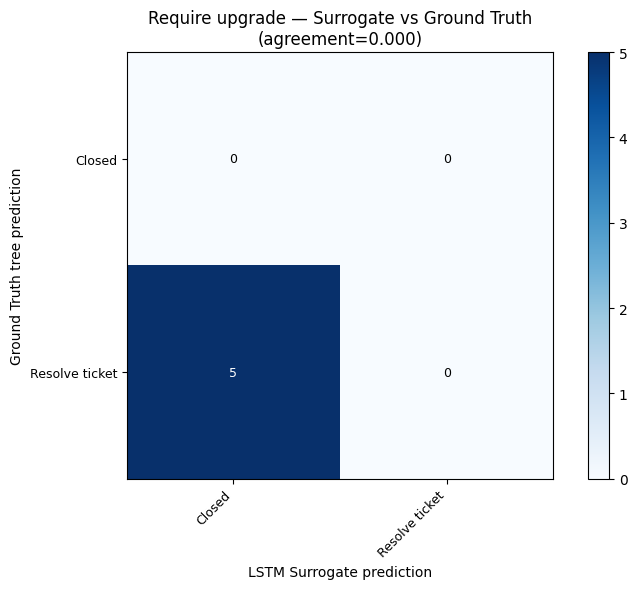

In [10]:
for gateway_act, gr in gateway_results.items():
    y_surr = gr['clf_lstm'].predict(gr['X_test'])
    y_gt = gr['clf_gt'].predict(gr['X_test'])

    labels = sorted(set(y_surr) | set(y_gt))
    cm = confusion_matrix(y_gt, y_surr, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('LSTM Surrogate prediction')
    ax.set_ylabel('Ground Truth tree prediction')
    ax.set_title(f'{gateway_act} — Surrogate vs Ground Truth\n(agreement={gr["agreement"]:.3f})')
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

## Deep dive: disagreement analysis

For the gateway with the lowest agreement rate, examine individual test cases
where the surrogate and ground truth trees predict different branches. Shows
what the LSTM actually predicted vs what happened, and which features are at
play.

In [11]:
# Find gateway with lowest agreement
worst_gateway = min(gateway_results, key=lambda g: gateway_results[g]['agreement'])
gr = gateway_results[worst_gateway]
print(f'Deepest disagreement: {worst_gateway} (agreement={gr["agreement"]:.3f})\n')

y_surr = gr['clf_lstm'].predict(gr['X_test'])
y_gt_pred = gr['clf_gt'].predict(gr['X_test'])
disagree_mask = y_surr != y_gt_pred
disagree_indices = np.where(disagree_mask)[0]

n_show = min(8, len(disagree_indices))
rng = np.random.RandomState(42)
show_indices = rng.choice(disagree_indices, size=n_show, replace=False) if len(disagree_indices) > 0 else []

for idx in show_indices:
    sample = gr['X_test'].iloc[idx]
    lstm_pred = gr['y_lstm_test'].iloc[idx] if hasattr(gr['y_lstm_test'], 'iloc') else gr['y_lstm_test'][idx]
    actual = gr['y_actual_test'].iloc[idx] if hasattr(gr['y_actual_test'], 'iloc') else gr['y_actual_test'][idx]
    surr_pred = y_surr[idx]
    gt_pred = y_gt_pred[idx]

    print(f'{"=" * 80}')
    print(f'Actual next: {actual} | LSTM predicted: {lstm_pred}')
    print(f'Surrogate tree: {surr_pred} | GT tree: {gt_pred}')

    print(f'\n  Surrogate path:')
    for i, step in enumerate(gr['clf_lstm'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {surr_pred}')

    print(f'\n  GT path:')
    for i, step in enumerate(gr['clf_gt'].explain_decision_path(sample)):
        print(f'    {i+1}. {step}')
    print(f'    -> {gt_pred}')
    print()

Deepest disagreement: Insert ticket (agreement=0.000)

Actual next: Assign seriousness | LSTM predicted: Take in charge ticket
Surrogate tree: Take in charge ticket | GT tree: Assign seriousness

  Surrogate path:
    -> Take in charge ticket

  GT path:
    -> Assign seriousness

Actual next: Assign seriousness | LSTM predicted: Take in charge ticket
Surrogate tree: Take in charge ticket | GT tree: Assign seriousness

  Surrogate path:
    -> Take in charge ticket

  GT path:
    -> Assign seriousness

Actual next: Assign seriousness | LSTM predicted: Take in charge ticket
Surrogate tree: Take in charge ticket | GT tree: Assign seriousness

  Surrogate path:
    -> Take in charge ticket

  GT path:
    -> Assign seriousness

Actual next: Assign seriousness | LSTM predicted: Take in charge ticket
Surrogate tree: Take in charge ticket | GT tree: Assign seriousness

  Surrogate path:
    -> Take in charge ticket

  GT path:
    -> Assign seriousness

Actual next: Assign seriousness | LST

## Depth sweep comparison

Shows how validation fidelity/accuracy evolves with tree depth for both
trees at each gateway. These curves are used only for depth selection;
test-set performance is reported once in the summary table. Helps judge
the interpretability-accuracy tradeoff.

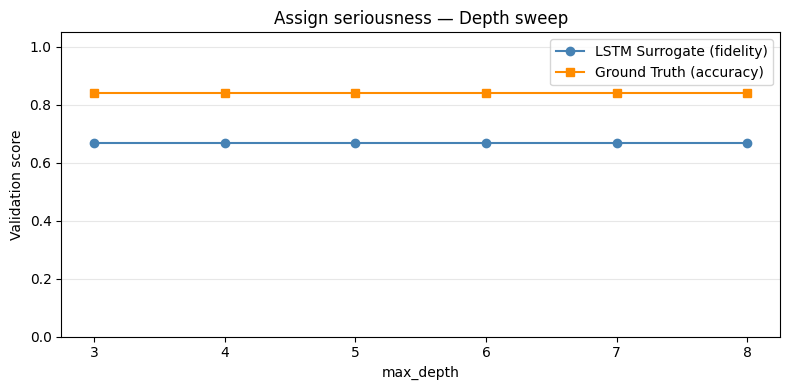

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.633,0.668,3,0.839,0.839,1
1,4,0.633,0.668,3,0.839,0.839,1
2,5,0.633,0.668,3,0.839,0.839,1
3,6,0.633,0.668,3,0.839,0.839,1
4,7,0.633,0.668,3,0.839,0.839,1
5,8,0.633,0.668,3,0.839,0.839,1


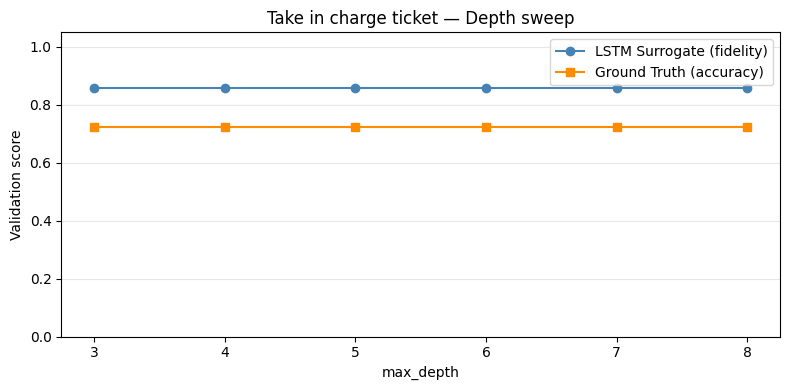

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.861,0.859,4,0.729,0.724,4
1,4,0.861,0.859,4,0.729,0.724,4
2,5,0.861,0.859,4,0.729,0.724,4
3,6,0.861,0.859,4,0.729,0.724,4
4,7,0.861,0.859,4,0.729,0.724,4
5,8,0.861,0.859,4,0.729,0.724,4


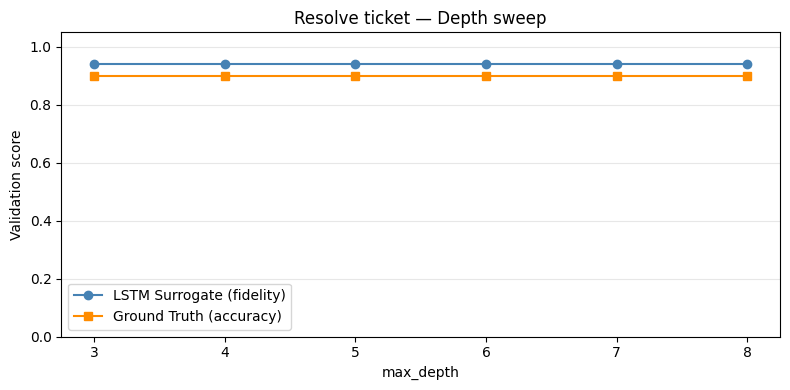

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.963,0.939,1,0.927,0.899,1
1,4,0.963,0.939,1,0.927,0.899,1
2,5,0.963,0.939,1,0.927,0.899,1
3,6,0.963,0.939,1,0.927,0.899,1
4,7,0.963,0.939,1,0.927,0.899,1
5,8,0.963,0.939,1,0.927,0.899,1


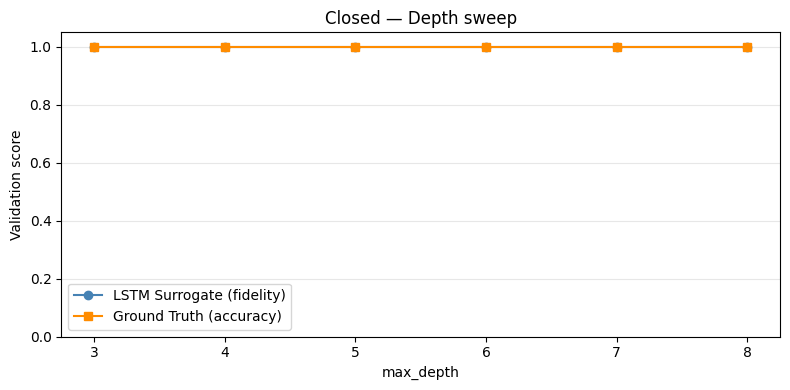

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,1.000,1.000,1,0.998,1.000,1
1,4,1.000,1.000,1,0.998,1.000,1
2,5,1.000,1.000,1,0.998,1.000,1
3,6,1.000,1.000,1,0.998,1.000,1
4,7,1.000,1.000,1,0.998,1.000,1
5,8,1.000,1.000,1,0.998,1.000,1


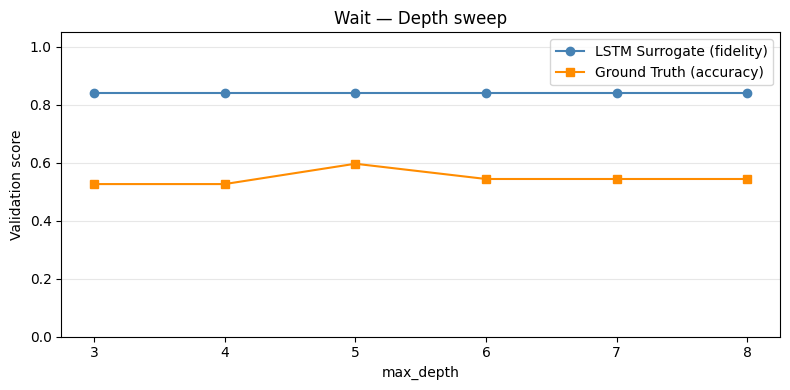

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.817,0.842,1,0.568,0.526,1
1,4,0.817,0.842,1,0.568,0.526,1
2,5,0.817,0.842,1,0.574,0.596,6
3,6,0.817,0.842,1,0.580,0.544,7
4,7,0.817,0.842,1,0.580,0.544,7
5,8,0.817,0.842,1,0.580,0.544,7


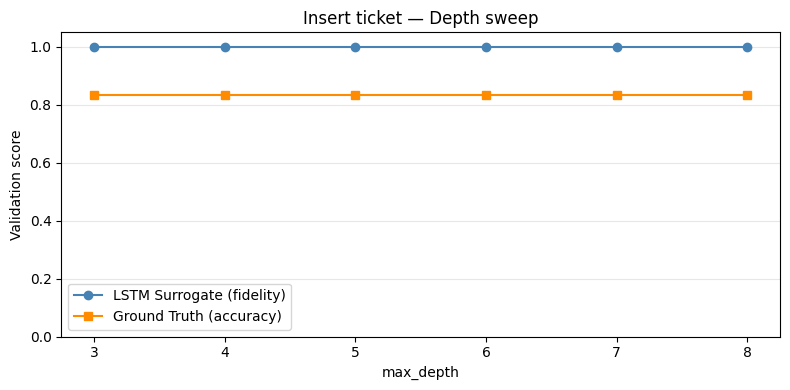

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,1.000,1.000,1,0.938,0.833,1
1,4,1.000,1.000,1,0.938,0.833,1
2,5,1.000,1.000,1,0.938,0.833,1
3,6,1.000,1.000,1,0.938,0.833,1
4,7,1.000,1.000,1,0.938,0.833,1
5,8,1.000,1.000,1,0.938,0.833,1


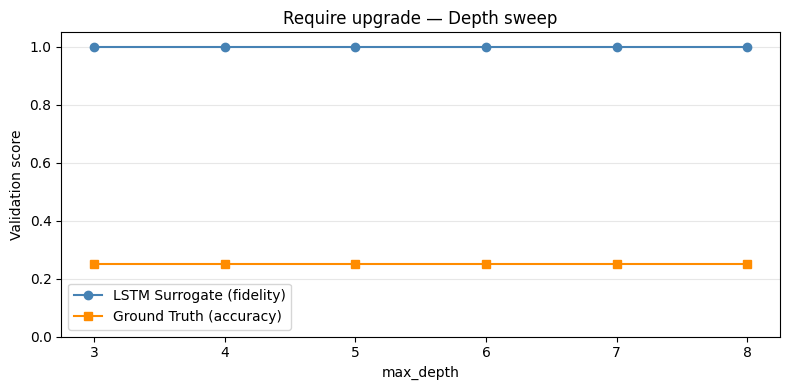

,depth,surr_train,surr_val,surr_leaves,gt_train,gt_val,gt_leaves
0,3,0.750,1.000,1,0.500,0.250,1
1,4,0.750,1.000,1,0.500,0.250,1
2,5,0.750,1.000,1,0.500,0.250,1
3,6,0.750,1.000,1,0.500,0.250,1
4,7,0.750,1.000,1,0.500,0.250,1
5,8,0.750,1.000,1,0.500,0.250,1


In [12]:
for gateway_act, gr in gateway_results.items():
    lstm_sw = gr['lstm_sweep']
    gt_sw = gr['gt_sweep']

    depths_label = [str(r['depth']) if r['depth'] is not None else 'None' for r in lstm_sw]
    lstm_val = [r['val'] for r in lstm_sw]
    gt_val = [r['val'] for r in gt_sw]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(depths_label))
    ax.plot(x, lstm_val, 'o-', color='steelblue', label='LSTM Surrogate (fidelity)')
    ax.plot(x, gt_val, 's-', color='darkorange', label='Ground Truth (accuracy)')
    ax.set_xticks(x)
    ax.set_xticklabels(depths_label)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Validation score')
    ax.set_title(f'{gateway_act} — Depth sweep')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Table
    rows = []
    for ls, gs in zip(lstm_sw, gt_sw):
        rows.append({
            'depth': ls['depth'] if ls['depth'] is not None else 'None',
            'surr_train': f'{ls["train"]:.3f}',
            'surr_val': f'{ls["val"]:.3f}',
            'surr_leaves': ls['clf'].get_n_leaves(),
            'gt_train': f'{gs["train"]:.3f}',
            'gt_val': f'{gs["val"]:.3f}',
            'gt_leaves': gs['clf'].get_n_leaves(),
        })
    display(pd.DataFrame(rows))

## Side-by-side trees: Ground Truth vs LSTM Surrogate

For each gateway, the ground-truth decision tree (left) next to the LSTM
surrogate tree (right). Orange nodes are internal splits; blue nodes are leaves
showing the predicted class, sample count and confidence. Subtrees whose leaves
all predict the same class have been collapsed (same-prediction pruning).

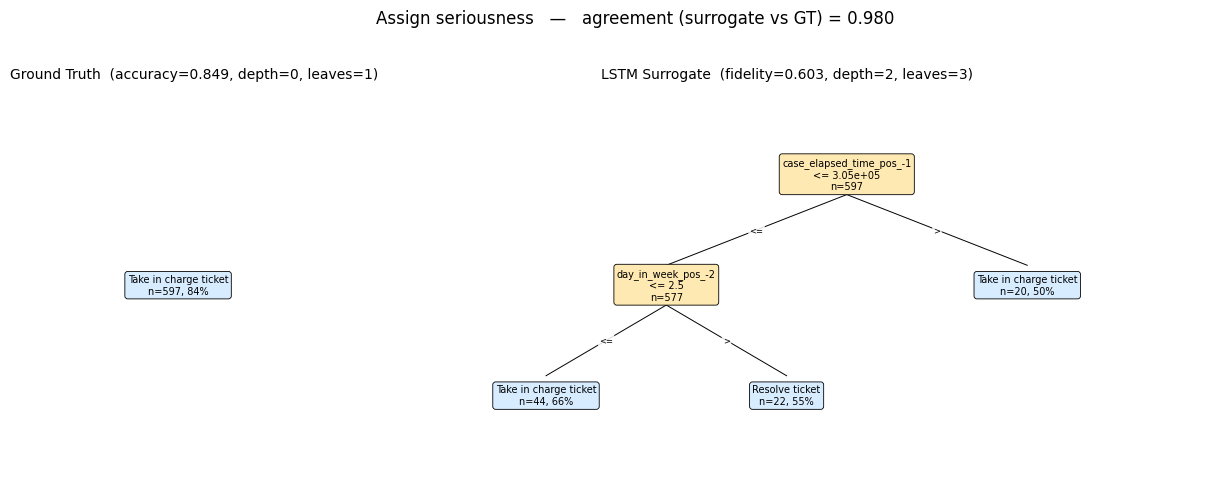

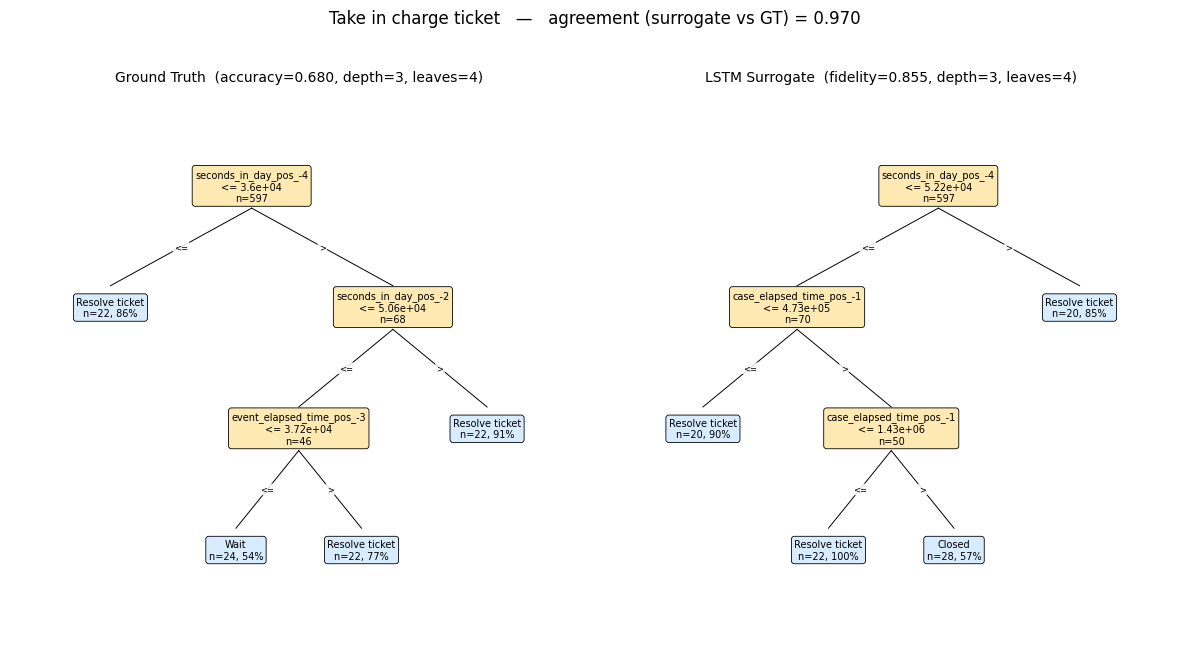

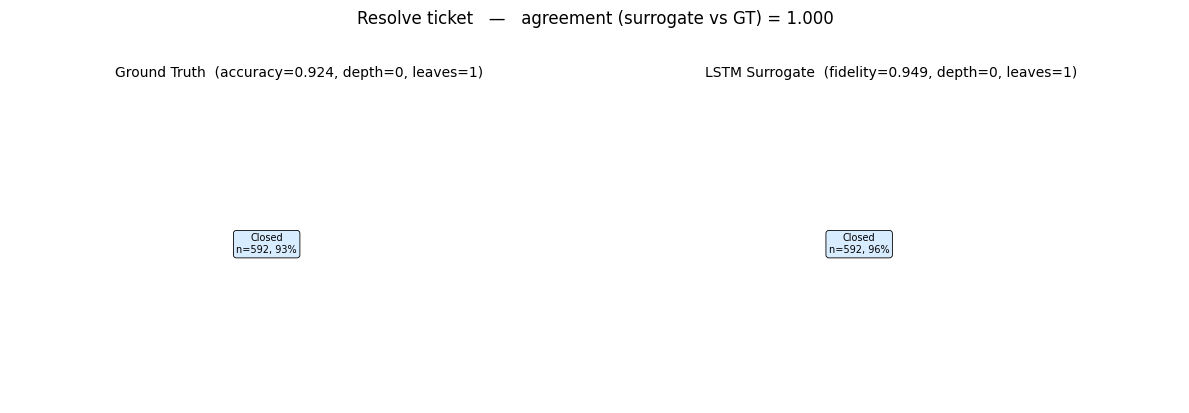

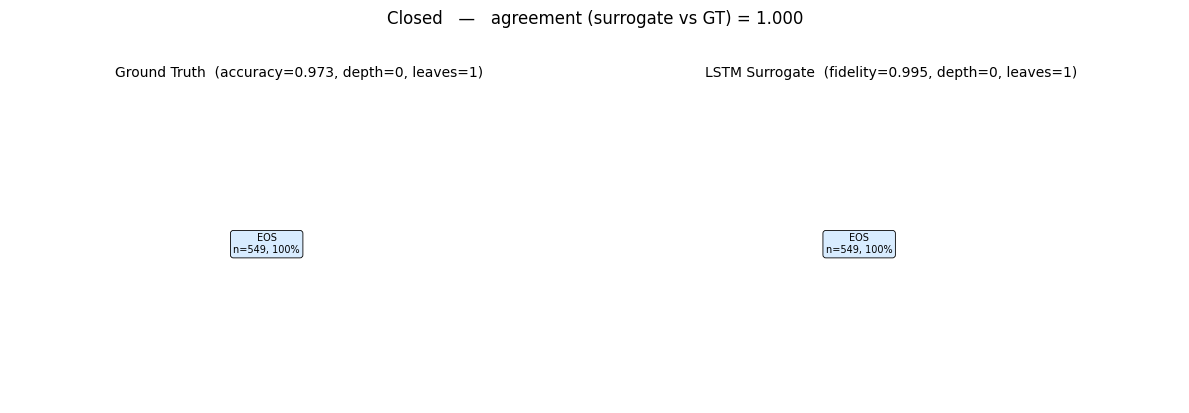

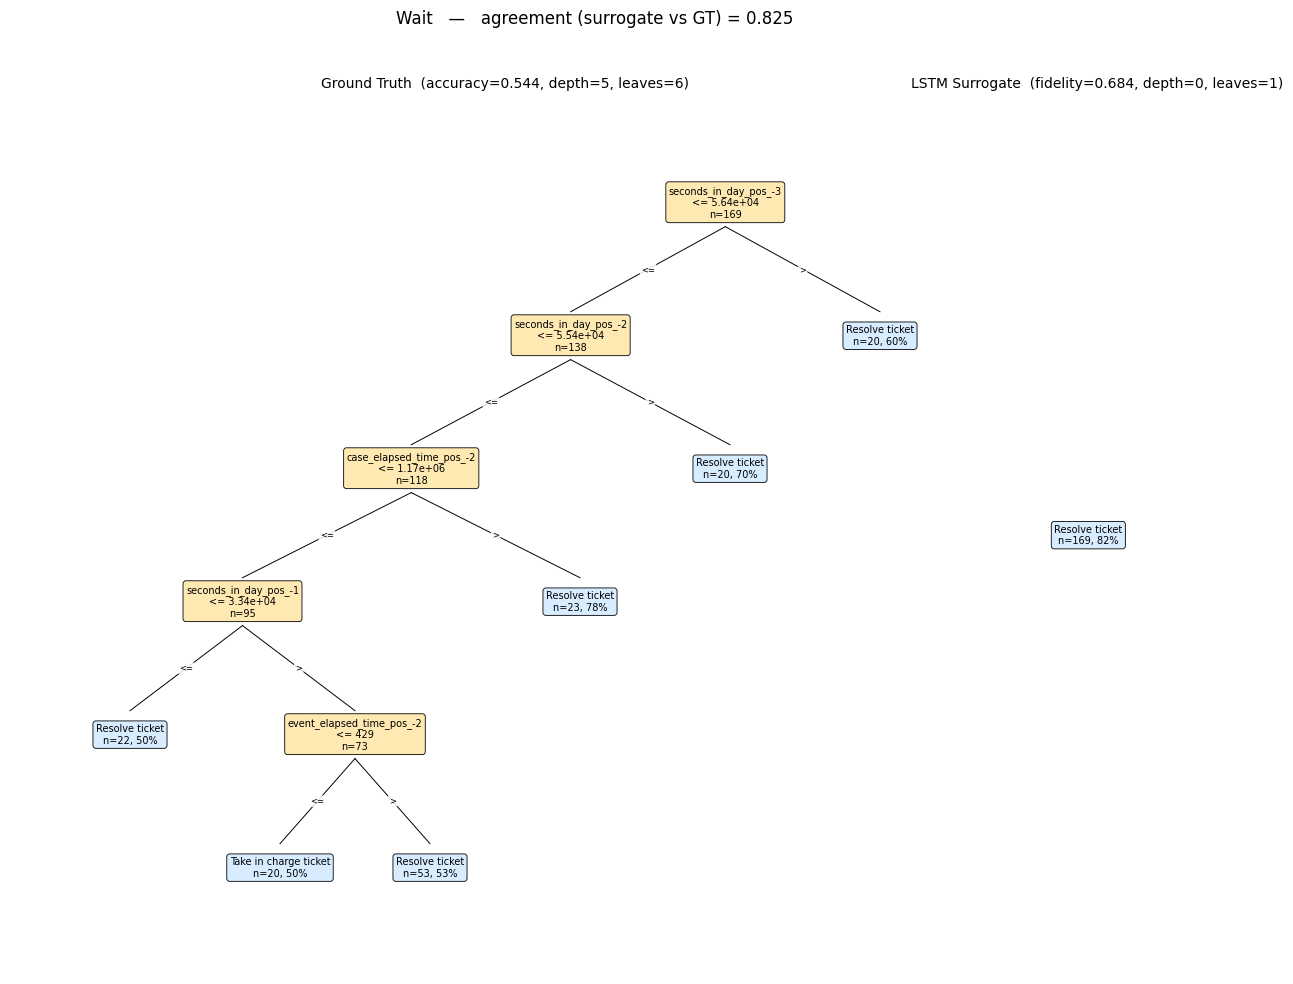

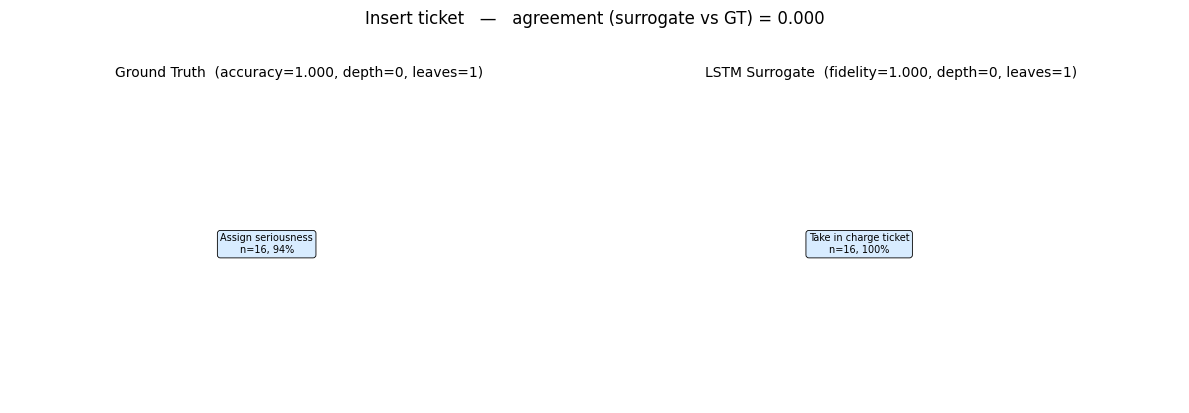

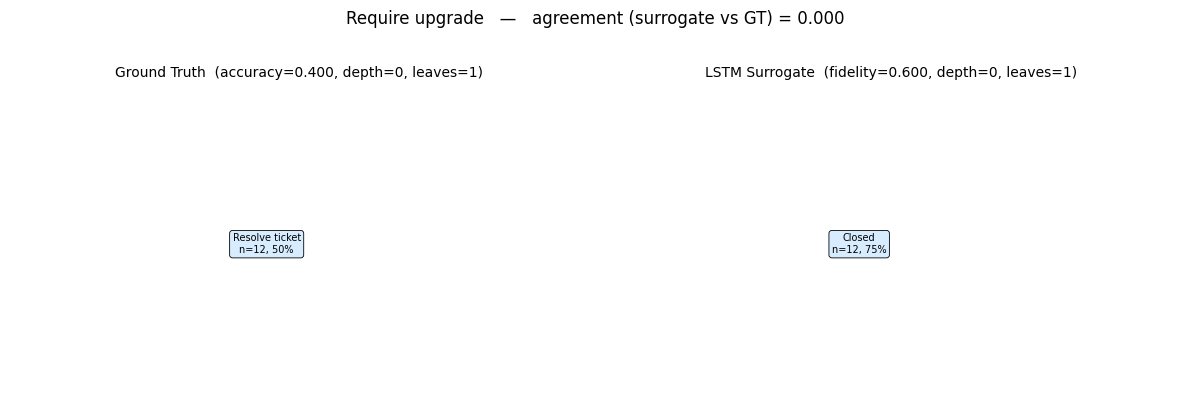

In [13]:
def plot_c45_tree_ax(clf, ax, title=''):
    """Render a C4.5 tree into a given matplotlib axis."""
    root = clf.root_
    if root is None:
        return

    positions = {}
    leaf_counter = [0]

    def assign_x(node, depth):
        if not node.children:
            positions[id(node)] = (leaf_counter[0], -depth)
            leaf_counter[0] += 1
            return positions[id(node)][0]
        child_xs = [assign_x(c, depth + 1) for c in node.children]
        x = (min(child_xs) + max(child_xs)) / 2.0
        positions[id(node)] = (x, -depth)
        return x

    assign_x(root, 0)
    max_depth = clf.get_depth()
    n_leaves = clf.get_n_leaves()

    def fmt_cat_label(lbl):
        if isinstance(lbl, (list, tuple, set, frozenset)):
            vals = [str(v) for v in lbl]
            if len(vals) > 3:
                return '{' + ', '.join(vals[:3]) + f', +{len(vals) - 3}' + '}'
            return '{' + ', '.join(vals) + '}'
        return str(lbl)

    def draw(node):
        x, y = positions[id(node)]
        is_leaf = not node.children
        if is_leaf:
            total = sum(node.class_distribution.values())
            conf = (node.class_distribution.get(node.majority_class, 0) / total) if total else 0
            text = f'{node.majority_class}\nn={node.n_samples}, {conf:.0%}'
            color = '#d8ecff'
        else:
            if node.is_categorical:
                text = f'{node.feature}\nn={node.n_samples}'
            else:
                text = f'{node.feature}\n<= {node.threshold:.3g}\nn={node.n_samples}'
            color = '#ffe9b3'
        ax.text(x, y, text, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                          edgecolor='black', linewidth=0.6))
        if is_leaf:
            return
        for i, child in enumerate(node.children):
            cx, cy = positions[id(child)]
            ax.plot([x, cx], [y - 0.18, cy + 0.18], 'k-', lw=0.7)
            if node.is_categorical:
                lbl = node.branch_labels[i] if i < len(node.branch_labels) else str(i)
                edge_text = fmt_cat_label(lbl)
            else:
                edge_text = '<=' if i == 0 else '>'
            mx, my = (x + cx) / 2, (y + cy) / 2
            ax.text(mx, my, edge_text, fontsize=6, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor='none', alpha=0.85))
            draw(child)

    draw(root)
    ax.set_xlim(-0.8, max(n_leaves - 0.2, 1.0))
    ax.set_ylim(-max_depth - 0.8, 0.8)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)


# --- Side-by-side Ground Truth vs Surrogate per gateway ---
for gateway_act, gr in gateway_results.items():
    gt_clf = gr['clf_gt']
    surr_clf = gr['clf_lstm']

    gt_leaves = max(gt_clf.get_n_leaves(), 1)
    surr_leaves = max(surr_clf.get_n_leaves(), 1)
    gt_depth = gt_clf.get_depth()
    surr_depth = surr_clf.get_depth()

    max_depth = max(gt_depth, surr_depth)
    fig_w = min(32, max(12, (gt_leaves + surr_leaves) * 1.4))
    fig_h = min(18, max(4, (max_depth + 1) * 1.6))

    fig, axes = plt.subplots(
        1, 2, figsize=(fig_w, fig_h),
        gridspec_kw={'width_ratios': [gt_leaves, surr_leaves]},
    )

    plot_c45_tree_ax(
        gt_clf, axes[0],
        title=f'Ground Truth  (accuracy={gr["gt_accuracy"]:.3f}, '
              f'depth={gt_depth}, leaves={gt_clf.get_n_leaves()})'
    )
    plot_c45_tree_ax(
        surr_clf, axes[1],
        title=f'LSTM Surrogate  (fidelity={gr["surrogate_fidelity"]:.3f}, '
              f'depth={surr_depth}, leaves={surr_clf.get_n_leaves()})'
    )
    fig.suptitle(
        f'{gateway_act}   —   agreement (surrogate vs GT) = {gr["agreement"]:.3f}',
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()

## Cache trained trees

Training the GT and surrogate trees across all qualifying gateways can take a while.
The cells below let you persist the current `gateway_data` + `gateway_results`
to a pickle file and reload them in a later session, skipping cells 6 and 8.

In [14]:
import pickle

CACHE_PATH = _current / 'cache' / '22_gateway_results_helpdesk.pkl'
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

_payload = {
    'gateway_data': gateway_data,
    'gateway_results': gateway_results,
    'feature_window': ACTIVITY_WINDOW,
    'event_cat_indices': EVENT_CAT_INDICES,
    'event_num_indices': EVENT_NUM_INDICES,
}
with open(CACHE_PATH, 'wb') as f:
    pickle.dump(_payload, f, protocol=pickle.HIGHEST_PROTOCOL)

_size_mb = CACHE_PATH.stat().st_size / 1024 / 1024
print(f'Saved {len(gateway_results)} gateways ({_size_mb:.1f} MB) -> {CACHE_PATH}')

Saved 7 gateways (7.4 MB) -> /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/cache/22_gateway_results_helpdesk.pkl


In [15]:
# Load cached trees — run this INSTEAD of cells 6 and 8 to skip re-training.
# Requires the earlier setup cells (model, decoder, predictor, decision_points)
# to have been run.
import pickle

CACHE_PATH = _current / 'cache' / '22_gateway_results_helpdesk.pkl'

with open(CACHE_PATH, 'rb') as f:
    _payload = pickle.load(f)

gateway_data = _payload['gateway_data']
gateway_results = _payload['gateway_results']

print(f'Loaded {len(gateway_results)} gateways from {CACHE_PATH}')
for _g, _r in gateway_results.items():
    print(f'  {_g:40s} fidelity={_r["surrogate_fidelity"]:.3f}, '
          f'gt_acc={_r["gt_accuracy"]:.3f}, agreement={_r["agreement"]:.3f}')

Loaded 7 gateways from /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/cache/22_gateway_results_helpdesk.pkl
  Assign seriousness                       fidelity=0.603, gt_acc=0.849, agreement=0.980
  Take in charge ticket                    fidelity=0.855, gt_acc=0.680, agreement=0.970
  Resolve ticket                           fidelity=0.949, gt_acc=0.924, agreement=1.000
  Closed                                   fidelity=0.995, gt_acc=0.973, agreement=1.000
  Wait                                     fidelity=0.684, gt_acc=0.544, agreement=0.825
  Insert ticket                            fidelity=1.000, gt_acc=1.000, agreement=0.000
  Require upgrade                          fidelity=0.600, gt_acc=0.400, agreement=0.000
